In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os
import pandas as pd

# Fig. 1e

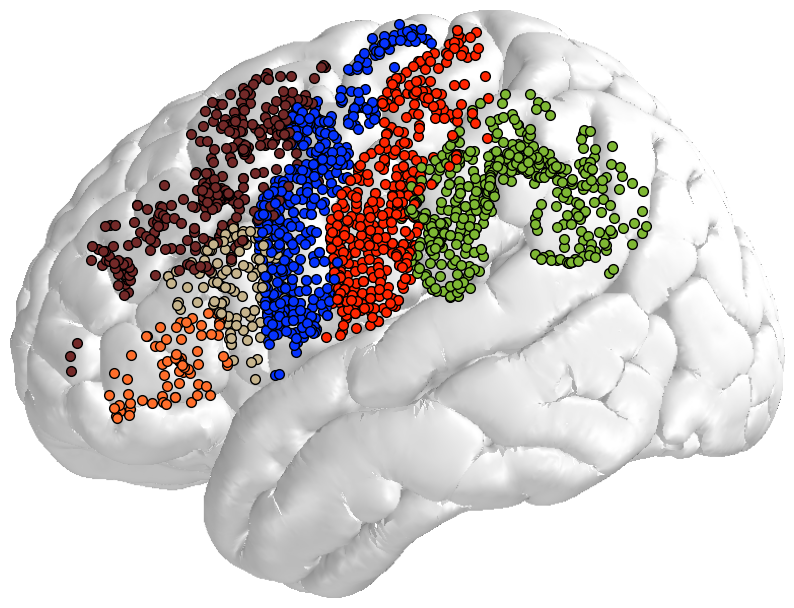

In [2]:
import pandas as pd
import matplotlib.image as mpimg

df = pd.read_excel(
    path+"/Source_Data.xlsx",
    sheet_name="Fig. 1e"
)

fig, ax = plt.subplots(figsize=(10,10))

img = mpimg.imread(path+"/elecs/MNI.png")
ax.imshow(img)

for _, row in df.iterrows():

    ax.plot(
        row["X"],
        row["Y"],
        marker='o',
        markersize=7,
        markeredgecolor='k',
        color=row["Color"],
        alpha=1
    )

ax.axis("off")

plt.show()

fig.savefig(path+"/figures_R3/Fig_1e.pdf",
            bbox_inches="tight")

# Ext. Fig. 1c

In [3]:
band_map = {
    'theta': 'θ',
    'alpha': 'α',
    'beta1': 'β1',
    'beta2': 'β2',
    'low_gamma': 'Lγ',
    'high_gamma':'Hγ'
}

band_order = [
    'θ',
    'α',
    'β1',
    'β2',
    'Lγ',
    'Hγ'
]

region_order = ['SMC', 'SMG', 'MFG', 'IFG']
source_file = os.path.join(path, "Source_Data.xlsx")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['font.weight'] = 'bold'
def get_p_symbol(p):
    """根据p值返回显著性符号"""
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "#"
    else:
        return "ns"
    

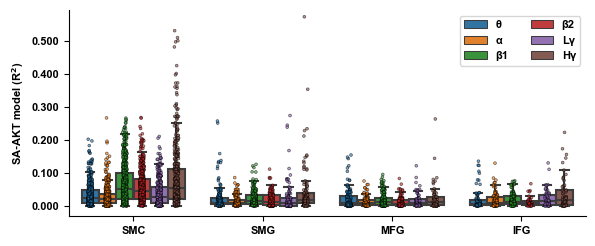


Median (IQR)
   Region Band    Median        Q1        Q3  Count
0     IFG   Hγ  0.020931  0.005646  0.049480     66
1     IFG   Lγ  0.015008  0.005005  0.034527     54
2     IFG    α  0.011913  0.003859  0.030139     85
3     IFG   β1  0.013983  0.007119  0.031800    106
4     IFG   β2  0.009228  0.005046  0.016994     42
5     IFG    θ  0.008157  0.004110  0.019139     80
6     MFG   Hγ  0.014118  0.004863  0.027951     75
7     MFG   Lγ  0.011744  0.005153  0.022190     68
8     MFG    α  0.009904  0.004926  0.018096    139
9     MFG   β1  0.011998  0.005275  0.026979    160
10    MFG   β2  0.007573  0.003246  0.021061    106
11    MFG    θ  0.010972  0.004714  0.030274    141
12    SMC   Hγ  0.054858  0.023261  0.114937    437
13    SMC   Lγ  0.028603  0.010044  0.058143    351
14    SMC    α  0.022418  0.010498  0.038520    429
15    SMC   β1  0.053360  0.023843  0.102451    563
16    SMC   β2  0.046784  0.023245  0.083269    489
17    SMC    θ  0.025645  0.011458  0.048571    44

In [4]:
taskname = 'overt'
abbr_map = {'overt':'SA','covert':'SI'}
alpha = 0.7
y_lim_map = {'overt':0.595,'covert':0.245}

############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Ext. Fig. 1c"
)

plot_df = plot_df[plot_df["Task"] == taskname].copy()

fig, ax = plt.subplots(figsize=(6, 2.5))

flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

region_order = ['SMC', 'SMG', 'MFG', 'IFG']

sns.boxplot(
    x='Region',
    y='R2',
    hue='Band',
    order=region_order,
    data=plot_df,
    flierprops=flierprops,
    showfliers=False
)

sns.stripplot(
    x='Region',
    y='R2',
    hue='Band',
    order=region_order,
    data=plot_df,
    dodge=True,
    jitter=True,
    alpha=0.6,
    linewidth=0.5,
    edgecolor="k",
    size=2,
    legend=False
)

plt.xlabel('')
plt.ylabel(f'{abbr_map[taskname]}-AKT model (R$^2$)', fontweight='bold')
plt.xticks(rotation=0)  # Rotate long region labels if needed.
plt.legend(title='', ncol=2)  # Arrange the legend in two columns.
# Remove the top and right spines.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-y_lim_map[taskname]/20, y_lim_map[taskname])

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
plt.tight_layout()

# Define the output path for the figure.
save_image_path = clean_data_path + f'/figures_R3/Exd_Fig_1c.tiff'  # Save the figure under its panel-specific filename.
plt.savefig(save_image_path, dpi=300) 
plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

import scipy.stats as stats
import itertools
import statsmodels.stats.multitest as smm

############################################################
# Calculate the median and interquartile range (IQR).
############################################################

grouped_stats = (
    plot_df
    .groupby(['Region', 'Band'])['R2']
    .agg(
        Median='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count='size'
    )
    .reset_index()
)

print("\nMedian (IQR)")
print(grouped_stats)

############################################################
# Run a Kruskal-Wallis test within each region.
############################################################

print("\n"+"="*60)
print("Kruskal-Wallis")
print("="*60)

kruskal_results = {}

for region in region_order:

    region_data = plot_df[plot_df["Region"] == region]

    grouped = [
        region_data[region_data["Band"] == band]["R2"].values
        for band in region_data["Band"].unique()
    ]

    H, p = stats.kruskal(*grouped)

    kruskal_results[region] = (H, p)

    print(f"{region}: H={H:.3f}, p={p:.4f}  {get_p_symbol(p)}")

############################################################
# Run pairwise Mann-Whitney U tests with FDR correction.
############################################################

print("\n"+"="*60)
print("Pairwise Mann-Whitney (FDR)")
print("="*60)

pairwise_results = []
for region in region_order:
    region_data = plot_df[plot_df["Region"] == region]
    bands_here = region_data["Band"].unique()
    comparisons = list(itertools.combinations(bands_here, 2))
    pvals = []
    for b1, b2 in comparisons:
        d1 = region_data.loc[
            region_data["Band"] == b1,
            "R2"
        ]
        d2 = region_data.loc[
            region_data["Band"] == b2,
            "R2"
        ]
        _, p = stats.mannwhitneyu(
            d1,
            d2,
            alternative="two-sided"
        )
        pvals.append(p)
    reject, pvals_fdr, _, _ = smm.multipletests(
        pvals,
        method="fdr_bh"
    )
    print(f"\n{region}")
    for (b1, b2), p in zip(comparisons, pvals_fdr):
        print(
            f"{b1} vs {b2}: "
            f"p={p:.4f} {get_p_symbol(p)}"
        )
        pairwise_results.append({
            "Region": region,
            "Comparison": f"{b1} vs {b2}",
            "FDR_p": p
        })
pairwise_results = pd.DataFrame(pairwise_results)

# Fig. 1g

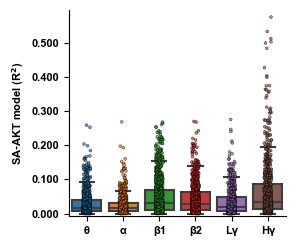


Median (IQR)
  Band    Median        Q1        Q3  Count
0    θ  0.018095  0.007627  0.041287    849
1    α  0.016388  0.006961  0.031176    797
2   β1  0.030638  0.011022  0.068954   1011
3   β2  0.029321  0.010087  0.062255    780
4   Lγ  0.018674  0.006682  0.047969    577
5   Hγ  0.034039  0.013675  0.086601    699

Kruskal-Wallis
H = 237.863, p = 2.206e-49 ****

Pairwise Mann-Whitney (FDR)
   Comparison         FDR_p Significance
0      θ vs α  1.451299e-02            *
1     θ vs β1  1.859292e-15         ****
2     θ vs β2  1.737278e-10         ****
3     θ vs Lγ  4.701832e-01           ns
4     θ vs Hγ  2.818677e-22         ****
5     α vs β1  2.715440e-25         ****
6     α vs β2  8.828233e-19         ****
7     α vs Lγ  5.023247e-03           **
8     α vs Hγ  3.724046e-32         ****
9    β1 vs β2  2.408603e-01           ns
10   β1 vs Lγ  1.814528e-09         ****
11   β1 vs Hγ  3.475212e-03           **
12   β2 vs Lγ  2.854516e-06         ****
13   β2 vs Hγ  1.504723e-04

In [5]:
############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Fig. 1g"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

fig, ax = plt.subplots(figsize=(3, 2.5))
palette = sns.color_palette(
    n_colors=plot_df['Band'].nunique()
)
flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

sns.boxplot(
    x='Band',
    y='R2',
    data=plot_df,
    order=band_order,
    flierprops=flierprops,
    showfliers=False
)

sns.stripplot(
    x='Band',
    y='R2',
    data=plot_df,
    order=band_order,
    palette=palette,
    linewidth=0.5,
    edgecolor="k",
    size=2,
    alpha=0.6
)

plt.xlabel('')
plt.ylabel(f'{abbr_map[taskname]}-AKT model (R$^2$)', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-y_lim_map[taskname]/80, y_lim_map[taskname])
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()

plt.savefig(
    clean_data_path + '/figures_R3/Fig_1g.tiff',
    dpi=300
)

plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

import scipy.stats as stats
import statsmodels.stats.multitest as smm
import itertools

############################################################
# Calculate the median and interquartile range (IQR).
############################################################

grouped_stats = (
    plot_df
    .groupby('Band')
    .agg(
        Median=('R2', 'median'),
        Q1=('R2', lambda x: x.quantile(0.25)),
        Q3=('R2', lambda x: x.quantile(0.75)),
        Count=('R2', 'size')
    )
    .reindex(band_order)
    .reset_index()
)

print("\nMedian (IQR)")
print(grouped_stats)

############################################################
# Run the Kruskal-Wallis test.
############################################################

grouped_data = [
    plot_df.loc[
        plot_df["Band"] == band,
        "R2"
    ]
    for band in band_order
]

H_stat, p_value = stats.kruskal(*grouped_data)

print("\n" + "="*60)
print("Kruskal-Wallis")
print("="*60)
print(f"H = {H_stat:.3f}, p = {p_value:.4g} {get_p_symbol(p_value)}")

############################################################
# Run pairwise Mann-Whitney U tests with FDR correction.
############################################################

if p_value < 0.05:

    comparisons = list(itertools.combinations(band_order, 2))

    p_values = []

    for band1, band2 in comparisons:

        data1 = plot_df.loc[
            plot_df["Band"] == band1,
            "R2"
        ]

        data2 = plot_df.loc[
            plot_df["Band"] == band2,
            "R2"
        ]

        _, p = stats.mannwhitneyu(
            data1,
            data2,
            alternative="two-sided"
        )

        p_values.append(p)

    reject, pvals_fdr, _, _ = smm.multipletests(
        p_values,
        method="fdr_bh"
    )

    pairwise_results = pd.DataFrame({
        "Comparison": [
            f"{a} vs {b}" for a, b in comparisons
        ],
        "FDR_p": pvals_fdr,
        "Significance": [
            get_p_symbol(p) for p in pvals_fdr
        ]
    })

    print("\n" + "="*60)
    print("Pairwise Mann-Whitney (FDR)")
    print("="*60)
    print(pairwise_results)

else:

    print("\nNo significant overall difference; pairwise tests were not performed.")

# Ext. Fig. 1a

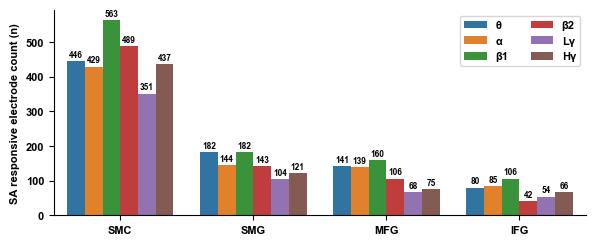

In [6]:
plot_df = pd.read_excel(
    source_file,
    sheet_name="Ext. Fig. 1a"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

fig, ax = plt.subplots(figsize=(6,2.5))

barplot = sns.barplot(
    x='Region',
    y='Count',
    hue='Band',
    data=plot_df,
    order=['SMC','SMG','MFG','IFG'],
    hue_order=band_order
)

for p in barplot.patches:

    height = p.get_height()

    ax.text(
        p.get_x()+p.get_width()/2,
        height+5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=6
    )

plt.xlabel('')

plt.ylabel(
    f'{abbr_map[taskname]} responsive electrode count (n)',
    fontweight='bold'
)

plt.legend(
    title='',
    ncol=2
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

save_image_path = (
    clean_data_path +
    '/figures_R3/Exd_Fig_1a.tiff'
)

plt.savefig(
    save_image_path,
    dpi=300
)

plt.show()

# Ext. Fig. 1d

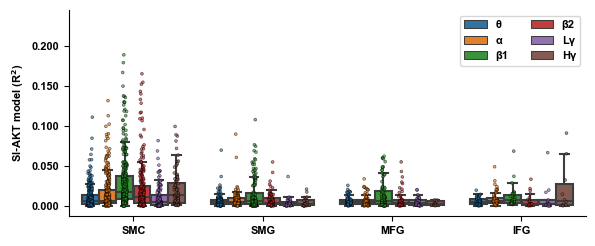


Median (IQR)
   Region Band    Median        Q1        Q3  Count
0     IFG   Hγ  0.007172  0.002067  0.028606     10
1     IFG   Lγ  0.003498  0.002550  0.008119     13
2     IFG    α  0.006801  0.004204  0.010065     47
3     IFG   β1  0.007536  0.004359  0.014564     32
4     IFG   β2  0.003088  0.002081  0.008240     22
5     IFG    θ  0.005650  0.002826  0.008886     43
6     MFG   Hγ  0.002745  0.001947  0.006182     10
7     MFG   Lγ  0.003881  0.002119  0.008404     29
8     MFG    α  0.005459  0.003534  0.008146     87
9     MFG   β1  0.007089  0.002714  0.019142     91
10    MFG   β2  0.004092  0.002452  0.008341     50
11    MFG    θ  0.005010  0.003052  0.008063     83
12    SMC   Hγ  0.013853  0.004649  0.029864     87
13    SMC   Lγ  0.005729  0.002203  0.014500     99
14    SMC    α  0.007256  0.003794  0.020679    285
15    SMC   β1  0.018583  0.008845  0.037391    356
16    SMC   β2  0.011315  0.004643  0.025947    244
17    SMC    θ  0.006608  0.003579  0.013711    27

In [7]:
taskname = 'covert'
abbr_map = {'overt':'SA','covert':'SI'}
alpha = 0.7
y_lim_map = {'overt':0.595,'covert':0.245}

############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Ext. Fig. 1d"
)

plot_df = plot_df[plot_df["Task"] == taskname].copy()

############################################################
# Step 4: create the plot.
############################################################

fig, ax = plt.subplots(figsize=(6, 2.5))

flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

region_order = ['SMC', 'SMG', 'MFG', 'IFG']

sns.boxplot(
    x='Region',
    y='R2',
    hue='Band',
    order=region_order,
    data=plot_df,
    flierprops=flierprops,
    showfliers=False
)

sns.stripplot(
    x='Region',
    y='R2',
    hue='Band',
    order=region_order,
    data=plot_df,
    dodge=True,
    jitter=True,
    alpha=0.6,
    linewidth=0.5,
    edgecolor="k",
    size=2,
    legend=False
)

plt.xlabel('')
plt.ylabel(f'{abbr_map[taskname]}-AKT model (R$^2$)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='', ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-y_lim_map[taskname]/20, y_lim_map[taskname])

ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.3f')
)

plt.tight_layout()

############################################################
# Save the figure.
############################################################

save_image_path = (
    clean_data_path +
    '/figures_R3/Exd_Fig_1d.tiff'
)

plt.savefig(save_image_path, dpi=300)

plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

import scipy.stats as stats
import itertools
import statsmodels.stats.multitest as smm

############################################################
# Calculate the median and interquartile range (IQR).
############################################################

grouped_stats = (
    plot_df
    .groupby(['Region', 'Band'])['R2']
    .agg(
        Median='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count='size'
    )
    .reset_index()
)

print("\nMedian (IQR)")
print(grouped_stats)

############################################################
# Run a Kruskal-Wallis test within each region.
############################################################

print("\n" + "="*60)
print("Kruskal-Wallis")
print("="*60)

kruskal_results = {}

for region in region_order:

    region_data = plot_df[
        plot_df["Region"] == region
    ]

    grouped = [
        region_data[
            region_data["Band"] == band
        ]["R2"].values
        for band in region_data["Band"].unique()
    ]

    H, p = stats.kruskal(*grouped)

    kruskal_results[region] = (H, p)

    print(
        f"{region}: "
        f"H={H:.3f}, "
        f"p={p:.4f} "
        f"{get_p_symbol(p)}"
    )

############################################################
# Run pairwise Mann-Whitney U tests with FDR correction.
############################################################

print("\n" + "="*60)
print("Pairwise Mann-Whitney (FDR)")
print("="*60)

pairwise_results = []

for region in region_order:

    region_data = plot_df[
        plot_df["Region"] == region
    ]

    bands_here = region_data["Band"].unique()

    comparisons = list(
        itertools.combinations(bands_here, 2)
    )

    pvals = []

    for b1, b2 in comparisons:

        d1 = region_data.loc[
            region_data["Band"] == b1,
            "R2"
        ]

        d2 = region_data.loc[
            region_data["Band"] == b2,
            "R2"
        ]

        _, p = stats.mannwhitneyu(
            d1,
            d2,
            alternative="two-sided"
        )

        pvals.append(p)

    reject, pvals_fdr, _, _ = smm.multipletests(
        pvals,
        method="fdr_bh"
    )

    print(f"\n{region}")

    for (b1, b2), p in zip(comparisons, pvals_fdr):

        print(
            f"{b1} vs {b2}: "
            f"p={p:.4f} "
            f"{get_p_symbol(p)}"
        )

        pairwise_results.append({
            "Region": region,
            "Comparison": f"{b1} vs {b2}",
            "FDR_p": p
        })

pairwise_results = pd.DataFrame(pairwise_results)

# Fig. 1i

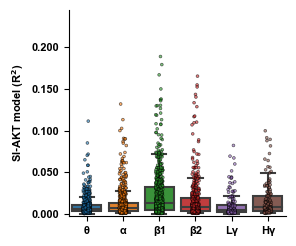


Median (IQR)
  Band    Median        Q1        Q3  Count
0    θ  0.005742  0.003264  0.010430    537
1    α  0.006633  0.003656  0.013132    545
2   β1  0.012412  0.004771  0.031708    618
3   β2  0.008024  0.003260  0.019231    409
4   Lγ  0.004217  0.002126  0.010627    176
5   Hγ  0.008222  0.003032  0.021866    130

Kruskal-Wallis
H = 139.842, p = 1.933e-28 ****

Pairwise Mann-Whitney (FDR)
   Comparison         FDR_p Significance
0      θ vs α  7.849441e-03           **
1     θ vs β1  9.233506e-24         ****
2     θ vs β2  5.667494e-04          ***
3     θ vs Lγ  1.513967e-02            *
4     θ vs Hγ  7.849441e-03           **
5     α vs β1  8.366288e-14         ****
6     α vs β2  2.199357e-01           ns
7     α vs Lγ  1.107893e-04          ***
8     α vs Hγ  2.199357e-01           ns
9    β1 vs β2  7.174270e-07         ****
10   β1 vs Lγ  2.428972e-15         ****
11   β1 vs Hγ  6.738990e-03           **
12   β2 vs Lγ  3.419540e-05         ****
13   β2 vs Hγ  6.954658e-01

In [8]:
############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Fig. 1i"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

############################################################
# Step 4: create the plot.
############################################################

fig, ax = plt.subplots(figsize=(3,2.5))

palette = sns.color_palette(
    n_colors=len(band_order)
)

flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

sns.boxplot(
    x='Band',
    y='R2',
    data=plot_df,
    order=band_order,
    flierprops=flierprops,
    showfliers=False
)

sns.stripplot(
    x='Band',
    y='R2',
    data=plot_df,
    order=band_order,
    palette=palette,
    linewidth=0.5,
    edgecolor='k',
    size=2,
    alpha=0.6
)

plt.xlabel('')

plt.ylabel(
    f'{abbr_map[taskname]}-AKT model (R$^2$)',
    fontweight='bold'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(
    -y_lim_map[taskname]/80,
    y_lim_map[taskname]
)

ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.3f')
)

plt.tight_layout()

plt.savefig(
    clean_data_path+'/figures_R3/Fig_1i.tiff',
    dpi=300
)

plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

import scipy.stats as stats
import itertools
import statsmodels.stats.multitest as smm

############################################################
# Calculate the median and interquartile range (IQR).
############################################################

grouped_stats = (
    plot_df
    .groupby("Band")
    .agg(
        Median=("R2","median"),
        Q1=("R2",lambda x:x.quantile(0.25)),
        Q3=("R2",lambda x:x.quantile(0.75)),
        Count=("R2","size")
    )
    .reindex(band_order)
    .reset_index()
)

print("\nMedian (IQR)")
print(grouped_stats)

############################################################
# Run the Kruskal-Wallis test.
############################################################

grouped_data = [
    plot_df.loc[
        plot_df["Band"]==band,
        "R2"
    ]
    for band in band_order
]

H_stat,p_value = stats.kruskal(*grouped_data)

print("\n"+"="*60)
print("Kruskal-Wallis")
print("="*60)

print(
    f"H = {H_stat:.3f}, "
    f"p = {p_value:.4g} "
    f"{get_p_symbol(p_value)}"
)

############################################################
# Run pairwise Mann-Whitney U tests with FDR correction.
############################################################

if p_value < 0.05:

    comparisons = list(
        itertools.combinations(
            band_order,
            2
        )
    )

    p_values = []

    for band1,band2 in comparisons:

        data1 = plot_df.loc[
            plot_df["Band"]==band1,
            "R2"
        ]

        data2 = plot_df.loc[
            plot_df["Band"]==band2,
            "R2"
        ]

        _,p = stats.mannwhitneyu(
            data1,
            data2,
            alternative="two-sided"
        )

        p_values.append(p)

    reject,pvals_fdr,_,_ = smm.multipletests(
        p_values,
        method="fdr_bh"
    )

    pairwise_results = pd.DataFrame({

        "Comparison":[
            f"{a} vs {b}"
            for a,b in comparisons
        ],

        "FDR_p":pvals_fdr,

        "Significance":[
            get_p_symbol(p)
            for p in pvals_fdr
        ]

    })

    print("\n"+"="*60)
    print("Pairwise Mann-Whitney (FDR)")
    print("="*60)

    print(pairwise_results)

else:

    print(
        "\nNo significant overall difference; "
        "pairwise tests were not performed."
    )

# Ext. Fig. 1b

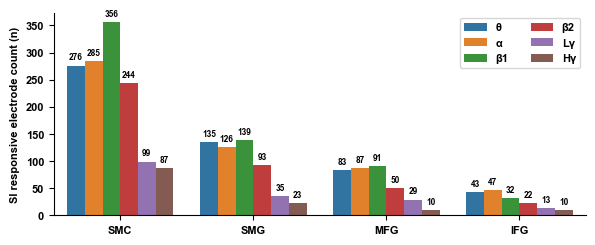

In [9]:
plot_df = pd.read_excel(
    source_file,
    sheet_name="Ext. Fig. 1b"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

fig, ax = plt.subplots(figsize=(6, 2.5))

region_order = ['SMC', 'SMG', 'MFG', 'IFG']

barplot = sns.barplot(
    x='Region',
    y='Count',
    hue='Band',
    data=plot_df,
    order=region_order,
    hue_order=band_order
)

# Scale the label offset to the largest count.
offset = plot_df["Count"].max() * 0.02

for p in barplot.patches:

    height = p.get_height()

    if np.isnan(height):
        continue

    ax.text(
        p.get_x() + p.get_width() / 2,
        height + offset,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=6
    )

plt.xlabel('')

plt.ylabel(
    f'{abbr_map[taskname]} responsive electrode count (n)',
    fontweight='bold'
)

plt.legend(
    title='',
    ncol=2
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

save_image_path = (
    clean_data_path +
    '/figures_R3/Exd_Fig_1b.tiff'
)

plt.savefig(
    save_image_path,
    dpi=300
)

plt.show()

# Fig. 1h

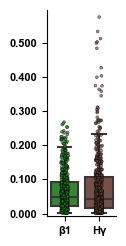


=== SA condition ===
Electrodes: 518
β1: median=0.049, Q1=0.024, Q3=0.093, N=518
Hγ: median=0.044, Q1=0.018, Q3=0.106, N=518
Wilcoxon signed-rank test: W=67048.000, p=0.9620


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import wilcoxon

taskname = 'overt'
abbr_map = {'overt':'SA','covert':'SI'}
alpha = 0.7
y_lim_map = {'overt':0.595,'covert':0.150}

############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Fig. 1h"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

############################################################
# Step 4: create the plot.
############################################################

df_melt = plot_df[
    ["β1", "Hγ"]
].melt(
    var_name="Band",
    value_name="R2"
)

fig, ax = plt.subplots(figsize=(1.3, 2.5))

flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

band_palette = {
    "β1": "#289228",
    "Hγ": "#7c4c42"
}

sns.boxplot(
    x="Band",
    y="R2",
    data=df_melt,
    flierprops=flierprops,
    showfliers=False,
    palette=band_palette
)

sns.stripplot(
    x="Band",
    y="R2",
    data=df_melt,
    palette=band_palette,
    linewidth=0.5,
    edgecolor="k",
    size=2,
    alpha=0.6
)

plt.xlabel("")
plt.ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(
    -y_lim_map[taskname]/80,
    y_lim_map[taskname]
)

ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.3f")
)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig_1h.tiff",
    dpi=300
)

plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

beta = plot_df["β1"]
gamma = plot_df["Hγ"]

stat, p = wilcoxon(beta, gamma)

def describe_series(series):
    return {
        "N": series.count(),
        "Median": series.median(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75)
    }

beta_desc = describe_series(beta)
gamma_desc = describe_series(gamma)

print(f"\n=== {abbr_map[taskname]} condition ===")
print(f"Electrodes: {len(plot_df)}")

print(
    f"β1: median={beta_desc['Median']:.3f}, "
    f"Q1={beta_desc['Q1']:.3f}, "
    f"Q3={beta_desc['Q3']:.3f}, "
    f"N={beta_desc['N']}"
)

print(
    f"Hγ: median={gamma_desc['Median']:.3f}, "
    f"Q1={gamma_desc['Q1']:.3f}, "
    f"Q3={gamma_desc['Q3']:.3f}, "
    f"N={gamma_desc['N']}"
)

print(
    f"Wilcoxon signed-rank test: "
    f"W={stat:.3f}, "
    f"p={p:.4f}"
)

# Fig. 1j

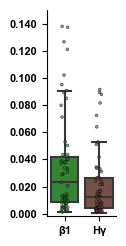


=== SI condition ===
Electrodes: 59
β1: median=0.023, Q1=0.009, Q3=0.042, N=59
Hγ: median=0.013, Q1=0.004, Q3=0.026, N=59
Wilcoxon signed-rank test: W=456.000, p=0.0012


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import wilcoxon

taskname = 'covert'
abbr_map = {'overt':'SA','covert':'SI'}
alpha = 0.7
y_lim_map = {'overt':0.595,'covert':0.150}

############################################################
# Step 3: read the Source Data workbook.
############################################################

plot_df = pd.read_excel(
    source_file,
    sheet_name="Fig. 1j"
)

plot_df = plot_df[
    plot_df["Task"] == taskname
].copy()

############################################################
# Step 4: create the plot.
############################################################

df_melt = plot_df[
    ["β1", "Hγ"]
].melt(
    var_name="Band",
    value_name="R2"
)

fig, ax = plt.subplots(figsize=(1.3, 2.5))

flierprops = dict(
    marker='o',
    markersize=3,
    linestyle='none',
    markerfacecolor='white'
)

band_palette = {
    "β1": "#289228",
    "Hγ": "#7c4c42"
}

sns.boxplot(
    x="Band",
    y="R2",
    data=df_melt,
    flierprops=flierprops,
    showfliers=False,
    palette=band_palette
)

sns.stripplot(
    x="Band",
    y="R2",
    data=df_melt,
    palette=band_palette,
    linewidth=0.5,
    edgecolor="k",
    size=2,
    alpha=0.6
)

plt.xlabel("")
plt.ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(
    -y_lim_map[taskname]/80,
    y_lim_map[taskname]
)

ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.3f")
)

plt.tight_layout()

plt.savefig(
    clean_data_path + "/figures_R3/Fig_1j.tiff",
    dpi=300
)

plt.show()

############################################################
# Step 5: calculate statistics.
############################################################

beta = plot_df["β1"]
gamma = plot_df["Hγ"]

stat, p = wilcoxon(beta, gamma)

def describe_series(series):
    return {
        "N": series.count(),
        "Median": series.median(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75)
    }

beta_desc = describe_series(beta)
gamma_desc = describe_series(gamma)

print(f"\n=== {abbr_map[taskname]} condition ===")
print(f"Electrodes: {len(plot_df)}")

print(
    f"β1: median={beta_desc['Median']:.3f}, "
    f"Q1={beta_desc['Q1']:.3f}, "
    f"Q3={beta_desc['Q3']:.3f}, "
    f"N={beta_desc['N']}"
)

print(
    f"Hγ: median={gamma_desc['Median']:.3f}, "
    f"Q1={gamma_desc['Q1']:.3f}, "
    f"Q3={gamma_desc['Q3']:.3f}, "
    f"N={gamma_desc['N']}"
)

print(
    f"Wilcoxon signed-rank test: "
    f"W={stat:.3f}, "
    f"p={p:.4f}"
)